Dataset
----

In [34]:
from nltk.lm import Vocabulary 
#nltk.download('all')

In [35]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics       import classification_report
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

import torch.nn.functional as F
import torch.nn as nn
from math import floor

import torch
torch.manual_seed(seed = 42)
device = torch.device('cpu') #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

import torch.nn as nn
from torch.utils.data        import DataLoader, TensorDataset
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import seaborn as sns

cpu


In [160]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds,_ = model(data_inputs)
        pred_labels = F.one_hot(preds.argmax(dim = 1),num_classes=3)

        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), y_true = all_labels.cpu().numpy(),  target_names  = target_names, zero_division = 0))

In [38]:
newsgroups_train = fetch_20newsgroups(data_home = '/Users/avaldivia/Documents/GitHub/Split-Learning/Data',
                                      subset    = 'all',
                                      download_if_missing = True,
                                      remove    = ('headers', 'footers', 'quotes'),
                                      categories= ['rec.motorcycles','rec.sport.baseball','sci.space'])

X, Y = newsgroups_train.data, newsgroups_train.target
print(len(X))
print(Y.shape)

2977
(2977,)


In [39]:
# Filter based on the number of words 
n_words_min = 100 # min([len(document.split()) for document in X]) -> 192 NOT INCLUDING EMPTY DESC

bool_len = lambda doc: True if len(doc.split()) >= n_words_min else False
mask = np.array([bool_len(document) for document in X])
Y = Y[mask]

X = [document for document in X if len(document.split()) >= n_words_min]
Counter(Y)

Counter({np.int64(2): 431, np.int64(1): 381, np.int64(0): 319})

---

In [40]:
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer
#from gensim.models import Word2Vec
#import gensim
#import nltk
#nltk.download('punkt_tab')
"""
[nltk_data] Downloading package punkt_tab to /home/drew/nltk_data...
[nltk_data] Package punkt_tab is already up-to-date!
"""
tokenizer = RegexpTokenizer(r'\w+')

In [41]:
#data = [[[ word for word in word_tokenize(sentence)] for sentence in sent_tokenize(sample)] for sample in X]
# Doesn't seem right since we are creating lists of sentences
data  = [tokenizer.tokenize(document) for document in X]
# Get the smallest seq
seq_len = min([len(document) for document in data]);
print(seq_len)
# Truncate each document to the shortest
data    = [document[:seq_len] for document in data]

93


In [42]:
all_words = set([word for sent in data for word in sent])
dc = {s:i for i,s in enumerate(sorted(all_words))}
sorted(list(dc.items()),key = lambda x: x[1])[:10]
print(len(dc.keys()))

13749


In [43]:
number_of_words = max(dc.values())
number_of_words

13748

In [44]:
#model1 = Word2Vec(data, min_count=1, vector_size=200, window=3)

In [45]:
embed = [[dc[w] for w in document] for document in data]

In [46]:
X = np.array(embed)

In [47]:
# (Samples, seq_len, embedding size)

----

In [49]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
Y = enc.fit_transform(Y.reshape(-1, 1),) # Should be (sampeles, 3)

In [50]:
Y.shape

(1131, 3)

X and Y are in the proper format for training.

In [ ]:
assert(len(X.shape)) == 2
samples, seq_len = X.shape
#X = X.reshape(samples,seq_len)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 64, shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [194]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.type(torch.float32).to(device)
            preds, alpha = model(data_inputs)
            preds = preds.type(torch.float32).to(device)
            
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss)

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [214]:
class Net(nn.Module):
    def __init__(self, label_space, num_of_words, embed_d, num_of_filters, kernel_size):
        super().__init__()
        self.embed = nn.Embedding(num_embeddings = num_of_words ,embedding_dim=embed_d, padding_idx=0)
        self.conv  = nn.Conv1d(embed_d, num_of_filters, kernel_size = kernel_size, padding = int(floor(3//2)))
        self.U     = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)
        self.embed_drop = nn.Dropout(p = 0.5)
        #self.attn  = nn.MultiheadAttention(embed_dim = 3, num_heads = 1)

    def forward(self, x):
        # x = F.relu(self.conv1(x))
        # batch, channel, seq_len, embed = x.shape
        # x   = x.reshape(batch,seq_len,embed)
        # x,_ = self.attn(x,x,x)
        # x = torch.flatten(x,start_dim=1)
        # #x = self.Drop_layers(x)
        # x = F.relu(self.fc1(x))
        # #x = self.Drop_layers(x)
        # x = self.fc2(x)
        # Embed
        x = self.embed (x)
        x = self.embed_drop(x)
        x = x.transpose (1, 2)
        #apply convolution and nonlinearity (tanh)
        x = F. tanh(self.conv(x).transpose(1,2))
        #apply attention
        alpha = F.softmax(self.U.weight.matmul(x. transpose (1,2)) , dim=2)
        #document representations are weighted sums using the attention. Can compute all at once as a matmul
        m = alpha.matmul(x)
        #Final layer classification
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)
        return y, alpha
    
model = Net(num_of_words   = number_of_words + 1, # + 1. The size of our vocabulary is 13748
            num_of_filters = 3,
            label_space    = 3, 
            kernel_size    = 5,
            embed_d        = 100)
model.to(device=device)


Net(
  (embed): Embedding(13749, 100, padding_idx=0)
  (conv): Conv1d(100, 3, kernel_size=(5,), stride=(1,), padding=(1,))
  (U): Linear(in_features=3, out_features=3, bias=True)
  (final): Linear(in_features=3, out_features=3, bias=True)
  (embed_drop): Dropout(p=0.5, inplace=False)
)

In [215]:
#loss_module = torch.nn.BCELoss()
#optimizer   = torch.optim.Adam(model.parameters(), lr=0.1, betas = (0.9,0.99)) #(0.1,0.3)

eval_model(model        = model,
           device       = device,
           data_loader  = train_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

                    precision    recall  f1-score   support

   rec.motorcycles       0.28      1.00      0.44       256
rec.sport.baseball       0.00      0.00      0.00       306
         sci.space       0.00      0.00      0.00       342

         micro avg       0.28      0.28      0.28       904
         macro avg       0.09      0.33      0.15       904
      weighted avg       0.08      0.28      0.12       904
       samples avg       0.28      0.28      0.28       904

                    precision    recall  f1-score   support

   rec.motorcycles       0.28      1.00      0.43        63
rec.sport.baseball       0.00      0.00      0.00        75
         sci.space       0.00      0.00      0.00        89

         micro avg       0.28      0.28      0.28       227
         macro avg       0.09      0.33      0.14       227
      weighted avg       0.08      0.28      0.12       227
       samples avg       0.28      0.28      0.28       227



In [217]:
loss_module = torch.nn.BCEWithLogitsLoss()
optimizer  = torch.optim.SGD(model.parameters(), lr = 0.1, momentum = 0.9)
#optimizer   = torch.optim.Adam(model.parameters(), lr=0.0001, betas =  (0.9,0.99)) #(0.1,0.3)

# saved_param = torch.load(f = '/home/drew/Split-Learning/ScratchWork/model.tar')
# model.load_state_dict(saved_param)

hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 100)

100%|██████████| 100/100 [00:59<00:00,  1.67it/s]


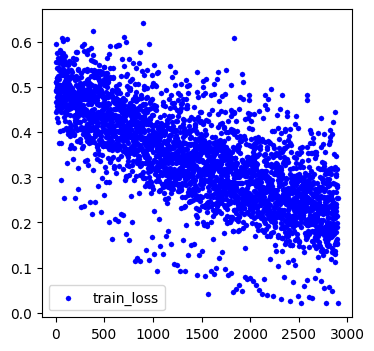

In [218]:
hist = [float(h.cpu().detach()) for h in hist]
plt.figure(figsize=(4,4))
plt.scatter(y = hist,

            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()
plt.show()

In [219]:
eval_model(model        = model,
           device       = device,
           data_loader  = train_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

"""
Best was:
0.6
0.7
0.9
"""

                    precision    recall  f1-score   support

   rec.motorcycles       0.90      0.96      0.93       256
rec.sport.baseball       0.99      0.93      0.96       306
         sci.space       0.96      0.97      0.96       342

         micro avg       0.95      0.95      0.95       904
         macro avg       0.95      0.95      0.95       904
      weighted avg       0.96      0.95      0.95       904
       samples avg       0.95      0.95      0.95       904

                    precision    recall  f1-score   support

   rec.motorcycles       0.66      0.71      0.69        63
rec.sport.baseball       0.88      0.68      0.77        75
         sci.space       0.72      0.82      0.77        89

         micro avg       0.74      0.74      0.74       227
         macro avg       0.75      0.74      0.74       227
      weighted avg       0.76      0.74      0.75       227
       samples avg       0.74      0.74      0.74       227



'\nBest was:\n0.6\n0.7\n0.9\n'

In [ ]:
#torch.save(model.state_dict(),f = '/home/drew/Split-Learning/ScratchWork/model.tar')

In [458]:
m = torch.arange(start = 1, end = 16).reshape(5,3)
m = F.one_hot(m.argmax(dim = 1),num_classes=3)

---

## Visualizing the importance of words

In [ ]:
sampling_dataset   = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 1, shuffle = False)
X_sample, Y_sample = next(iter(sampling_dataset))
(X_sample.shape, Y_sample.shape)

In [459]:
# Obtain our trained model
model

Net(
  (conv1): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=200, out_features=200, bias=True)
  )
  (fc1): Linear(in_features=18600, out_features=9700, bias=True)
  (fc2): Linear(in_features=9700, out_features=3, bias=True)
  (Drop_layers): Dropout(p=0.5, inplace=False)
)

In [ ]:
# print(X_sample.shape)
# ########################
# # Embed
# x = model.embed(X_sample) 
# print(x.shape)
# #x = x.squeeze(dim = 0)
# x = torch.transpose(x,1,2) # Tranpose #1 after embed
# ########################
# print(x.shape)
# x = torch.transpose (model.conv1(x),1,2) # Transpose #2 after convulution
# print(x.shape)
# ######################## Attention
# # x = torch.transpose(x,1,2) # Transpose for attention
# x = x.squeeze(dim = 0)
# print(x.shape)
# x,attn_map = model.attn(x,x,x)
# print(x.shape); print(attn_map.shape)
# ########################
# x = model.final(x)
# print(x.shape)
# x.T.sum(dim = 1).unsqueeze(dim = 0).shape

In [ ]:
plt.figure(figsize=(20,5))
plt.imshow(attn[0].detach().numpy())
plt.colorbar()
plt.show()

In [ ]:
#embed = [[model1.wv.get_vector(w) for w in document ] for document in data]
#X = torch.from_numpy(np.array(embed)).type(torch.float32)
#Y = torch.from_numpy(Y).type(torch.float32)
#sampling_dataset = DataLoader(TensorDataset(X,Y) , batch_size = 1, shuffle = False)

In [465]:
print(data[0])
labels = np.array(data)

['Okay', 'I', 'think', 'we', 'all', 'agree', 'that', 'singles', 'hitters', 'should', 'take', 'a', 'strike', 'or', 'two', 'and', 'try', 'to', 'get', 'on', 'base', 'any', 'way', 'they', 'can', 'So', 'the', 'No', 'Power', 'Impatient', 'guys', 'have', 'no', 'excuse', 'The', 'No', 'Power', 'Patient', 'guys', 'are', 'doing', 'the', 'right', 'thing', 'Now', 'the', 'Impatient', 'Power', 'guys', 'how', 'could', 'you', 'leave', 'out', 'the', 'Big', 'Cat', 'Would', 'these', 'guys', 'have', 'a', 'better', 'slugging', 'percentage', 'if', 'they', 'took', 'more', 'pitches', 'Perhaps', 'but', 'I', 'doubt', 'it', 'If', 'you', 'tell', 'Joe', 'Carter', 'to', 'go', 'up', 'there', 'and', 'take', 'a', 'few', 'pitches', 'he', 'will', 'draw', 'more']


In [466]:
sampling_dataset = [ (X_sample.reshape(1,1,93,200), Y_sample) for X_sample,Y_sample in iter(sampling_dataset)]
X_sample, Y_sample = sampling_dataset[25]
X_sample.shape, Y_sample.shape

(torch.Size([1, 1, 93, 200]), torch.Size([1, 3]))

In [467]:
x = model.conv1(X_sample)
x = x.reshape(93,200)
x, attn_map = model.attn(x,x,x)
x = x.detach().numpy()
attn_map = attn_map.detach().numpy()
...

Ellipsis

In [ ]:
# np.max(a = attn_map, axis = 1,keepdims=False)

In [468]:
target_names = ['rec.motorcycles','rec.sport.baseball','sci.space']
target_names[Y_sample.argmax(dim = 1)]

'rec.sport.baseball'

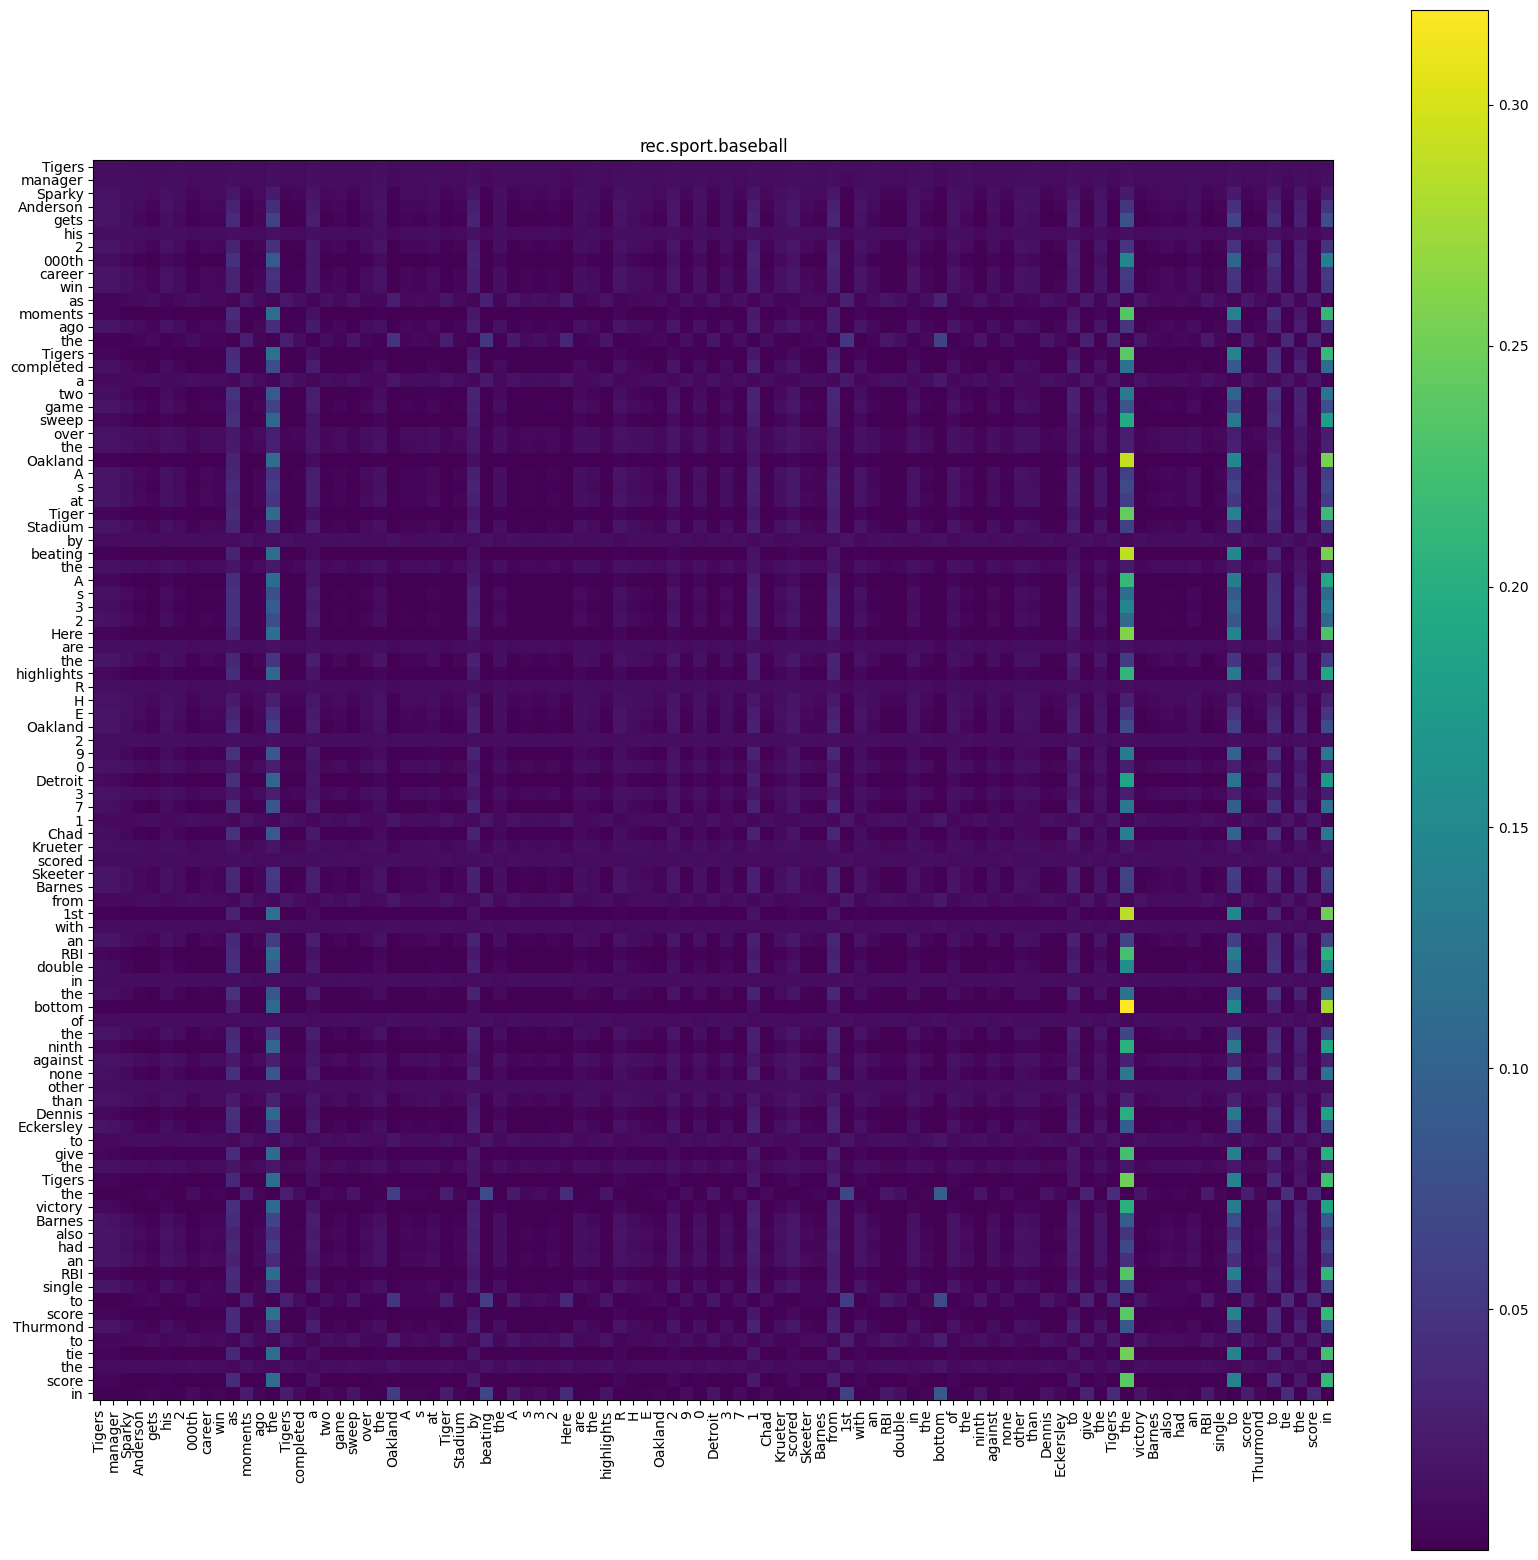

In [469]:
plt.figure(figsize=(20,20))
plt.title(label = target_names[Y_sample.argmax(dim = 1)])
plt.imshow(attn_map[:,:])
l = labels[25,:]
label_len = len(l)
plt.yticks(ticks = [_ for _ in range(label_len)], labels = l,rotation = 0)
l = labels[25,:]
label_len = len(l)
plt.xticks(ticks = [_ for _ in range(label_len)], labels = l,rotation = 90)
plt.colorbar()
plt.show()

In [ ]:
#sns.heatmap(attn_map[:5,46:],xticklabels=labels[:5],yticklabels=labels[46:], annot=True)

In [ ]:
(F.sigmoid(model(X_sample)) >= 0.5).long()

tensor([[1, 0, 1]])